# Notebook 2: EDA and Featurization
**Purpose:** Load raw data, generate MAGPIE composition features using `matminer`, create Exploratory Data Analysis (EDA) plots including target distribution, correlation heatmaps, and UMAP dimensionality reduction.

✅ Loaded 7786 compounds
✅ Removed existing 'composition' column

🔧 Generating MAGPIE features...


StrToComposition:   0%|          | 0/7786 [00:00<?, ?it/s]

ElementProperty:   0%|          | 0/7786 [00:00<?, ?it/s]

✅ Total features: 133
   MAGPIE: 132, Density: 1
✅ Saved to data/featurized_data.csv


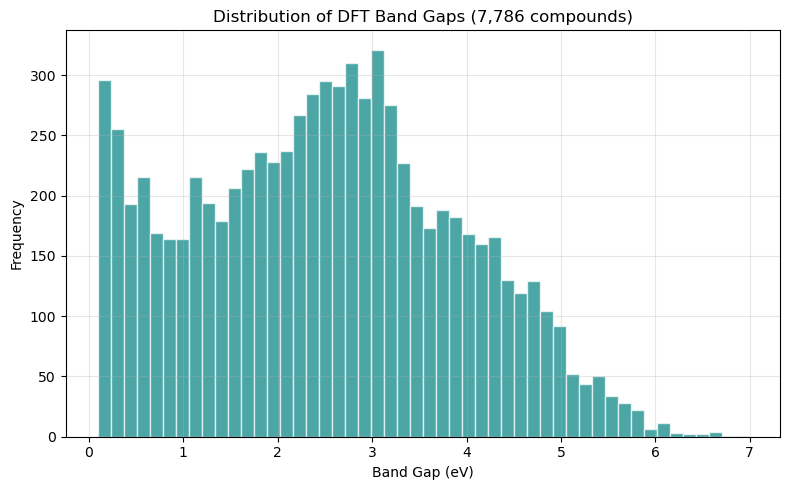

✅ Figure 1 saved


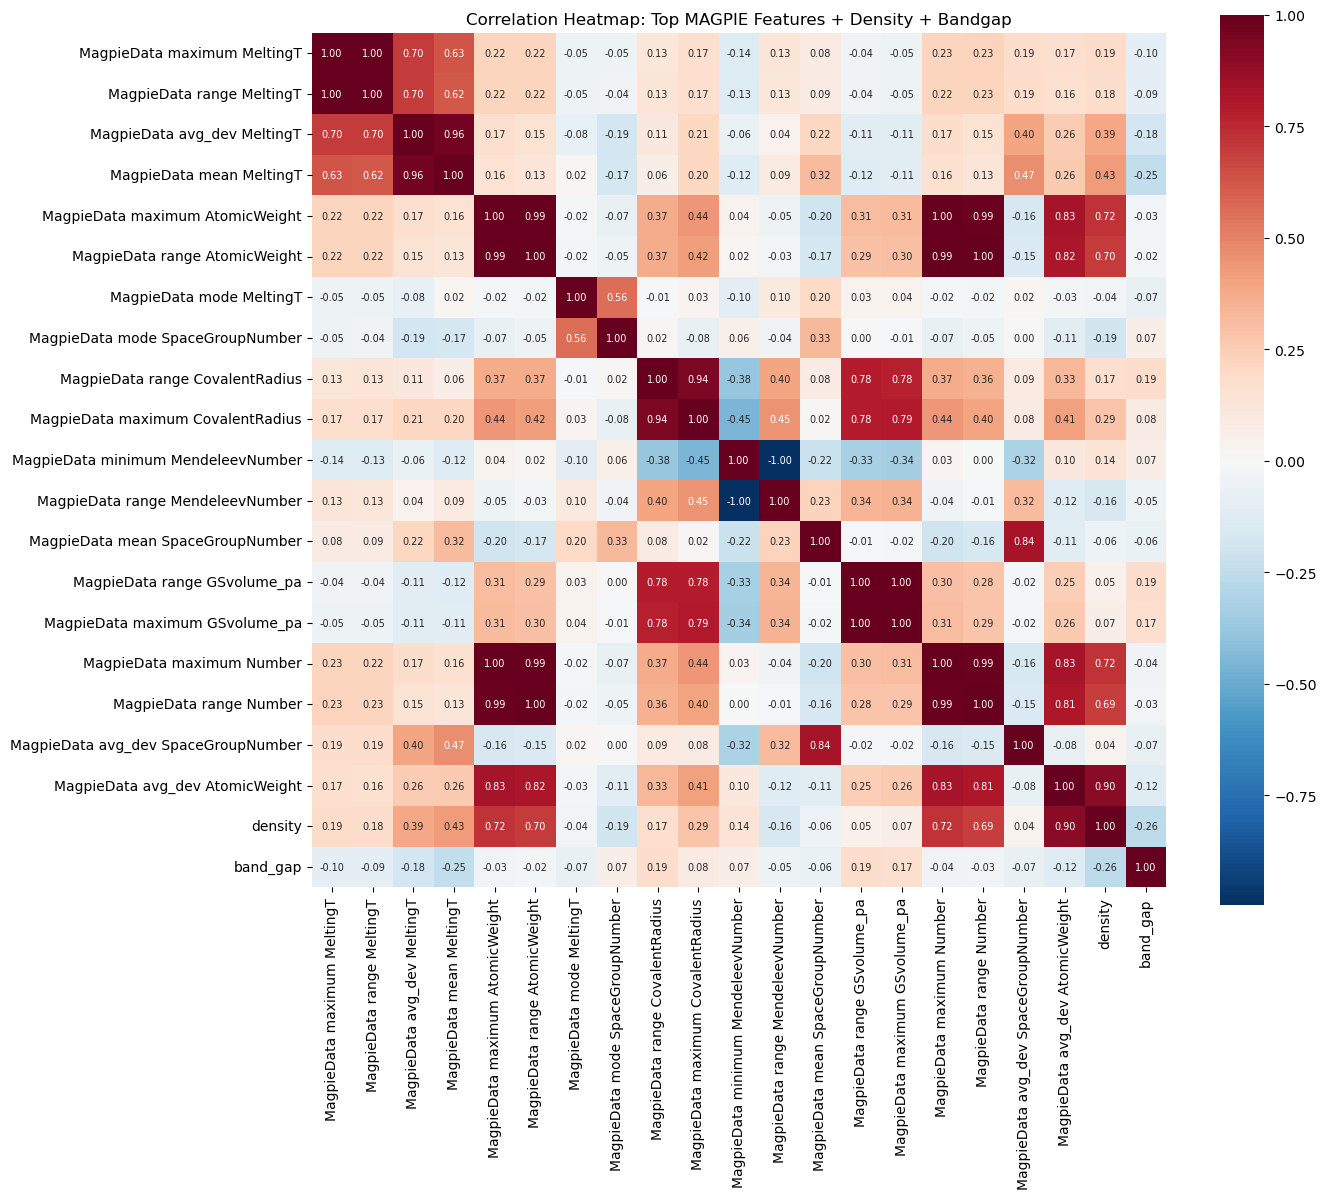

✅ Figure 2 saved

🌌 Generating UMAP embedding...


C:\Users\gkjsy\anaconda3\envs\matds\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


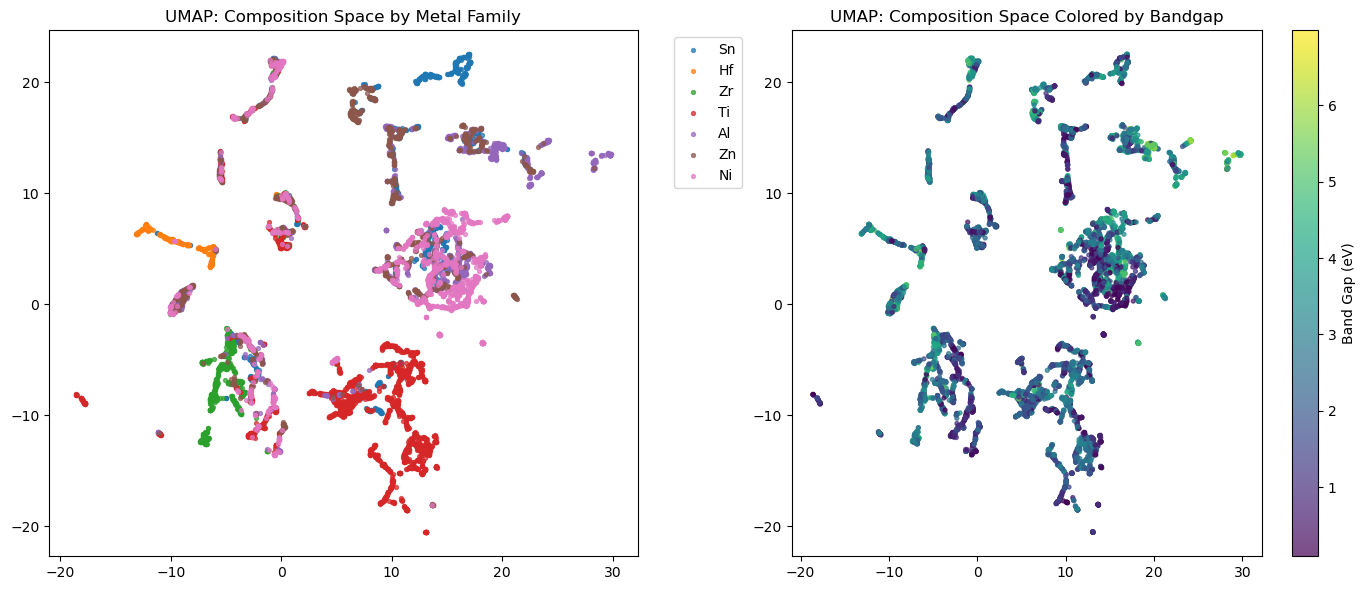

✅ Figure 3 saved

✅ Notebook 2 completed successfully!


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap

from pymatgen.core import Composition
from matminer.featurizers.conversions import StrToComposition
from matminer.featurizers.composition import ElementProperty

# Load raw data
df = pd.read_csv('data/heavy_metal_oxides.csv')
print(f"✅ Loaded {len(df)} compounds")

# Remove existing composition column to avoid conflict
if 'composition' in df.columns:
    df = df.drop(columns=['composition'])
    print("✅ Removed existing 'composition' column")

# Generate MAGPIE features
print("\n🔧 Generating MAGPIE features...")
df = StrToComposition(target_col_id='composition').featurize_dataframe(df, 'formula', ignore_errors=True)
ep = ElementProperty.from_preset('magpie')
df = ep.featurize_dataframe(df, 'composition', ignore_errors=True)

# MAGPIE columns
magpie_cols = [col for col in df.columns if col.startswith('MagpieData')]
feature_cols = magpie_cols + ['density']

print(f"✅ Total features: {len(feature_cols)}")
print(f"   MAGPIE: {len(magpie_cols)}, Density: 1")

# Save featurized data
os.makedirs('data', exist_ok=True)
df.to_csv('data/featurized_data.csv', index=False)
print("✅ Saved to data/featurized_data.csv")

# ============================================================
# Figure 1: Band Gap Distribution
# ============================================================
os.makedirs('figures', exist_ok=True)

plt.figure(figsize=(8, 5))
plt.hist(df['band_gap'], bins=50, color='teal', alpha=0.7, edgecolor='white')
plt.xlabel('Band Gap (eV)')
plt.ylabel('Frequency')
plt.title('Distribution of DFT Band Gaps (7,786 compounds)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/figure1_bandgap_distribution.png', dpi=150)
plt.show()
print("✅ Figure 1 saved")

# ============================================================
# Figure 2: Correlation Heatmap
# ============================================================
numeric_magpie_df = df[magpie_cols].apply(pd.to_numeric, errors='coerce')
top_magpie = numeric_magpie_df.var().nlargest(19).index.tolist()
selected_cols = top_magpie + ['density', 'band_gap']

plt.figure(figsize=(14, 12))
corr = df[selected_cols].apply(pd.to_numeric, errors='coerce').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, annot_kws={'size': 7})
plt.title('Correlation Heatmap: Top MAGPIE Features + Density + Bandgap')
plt.tight_layout()
plt.savefig('figures/figure2_correlation_heatmap.png', dpi=150)
plt.show()
print("✅ Figure 2 saved")

# ============================================================
# Figure 3: UMAP Composition Space
# ============================================================
print("\n🌌 Generating UMAP embedding...")

X_umap = numeric_magpie_df.fillna(0).astype(float).values
reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.3, random_state=42)
umap_embedding = reducer.fit_transform(X_umap)

df['umap1'] = umap_embedding[:, 0]
df['umap2'] = umap_embedding[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for metal in df['metal_group'].unique():
    subset = df[df['metal_group'] == metal]
    axes[0].scatter(subset['umap1'], subset['umap2'], label=metal, s=8, alpha=0.7)
axes[0].set_title('UMAP: Composition Space by Metal Family', fontsize=12)
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

sc = axes[1].scatter(df['umap1'], df['umap2'], c=df['band_gap'], cmap='viridis', s=8, alpha=0.7)
plt.colorbar(sc, ax=axes[1], label='Band Gap (eV)')
axes[1].set_title('UMAP: Composition Space Colored by Bandgap', fontsize=12)

plt.tight_layout()
plt.savefig('figures/figure3_umap_composition.png', dpi=150)
plt.show()
print("✅ Figure 3 saved")

print("\n✅ Notebook 2 completed successfully!")